# eval_harness — Pipeline Diagram

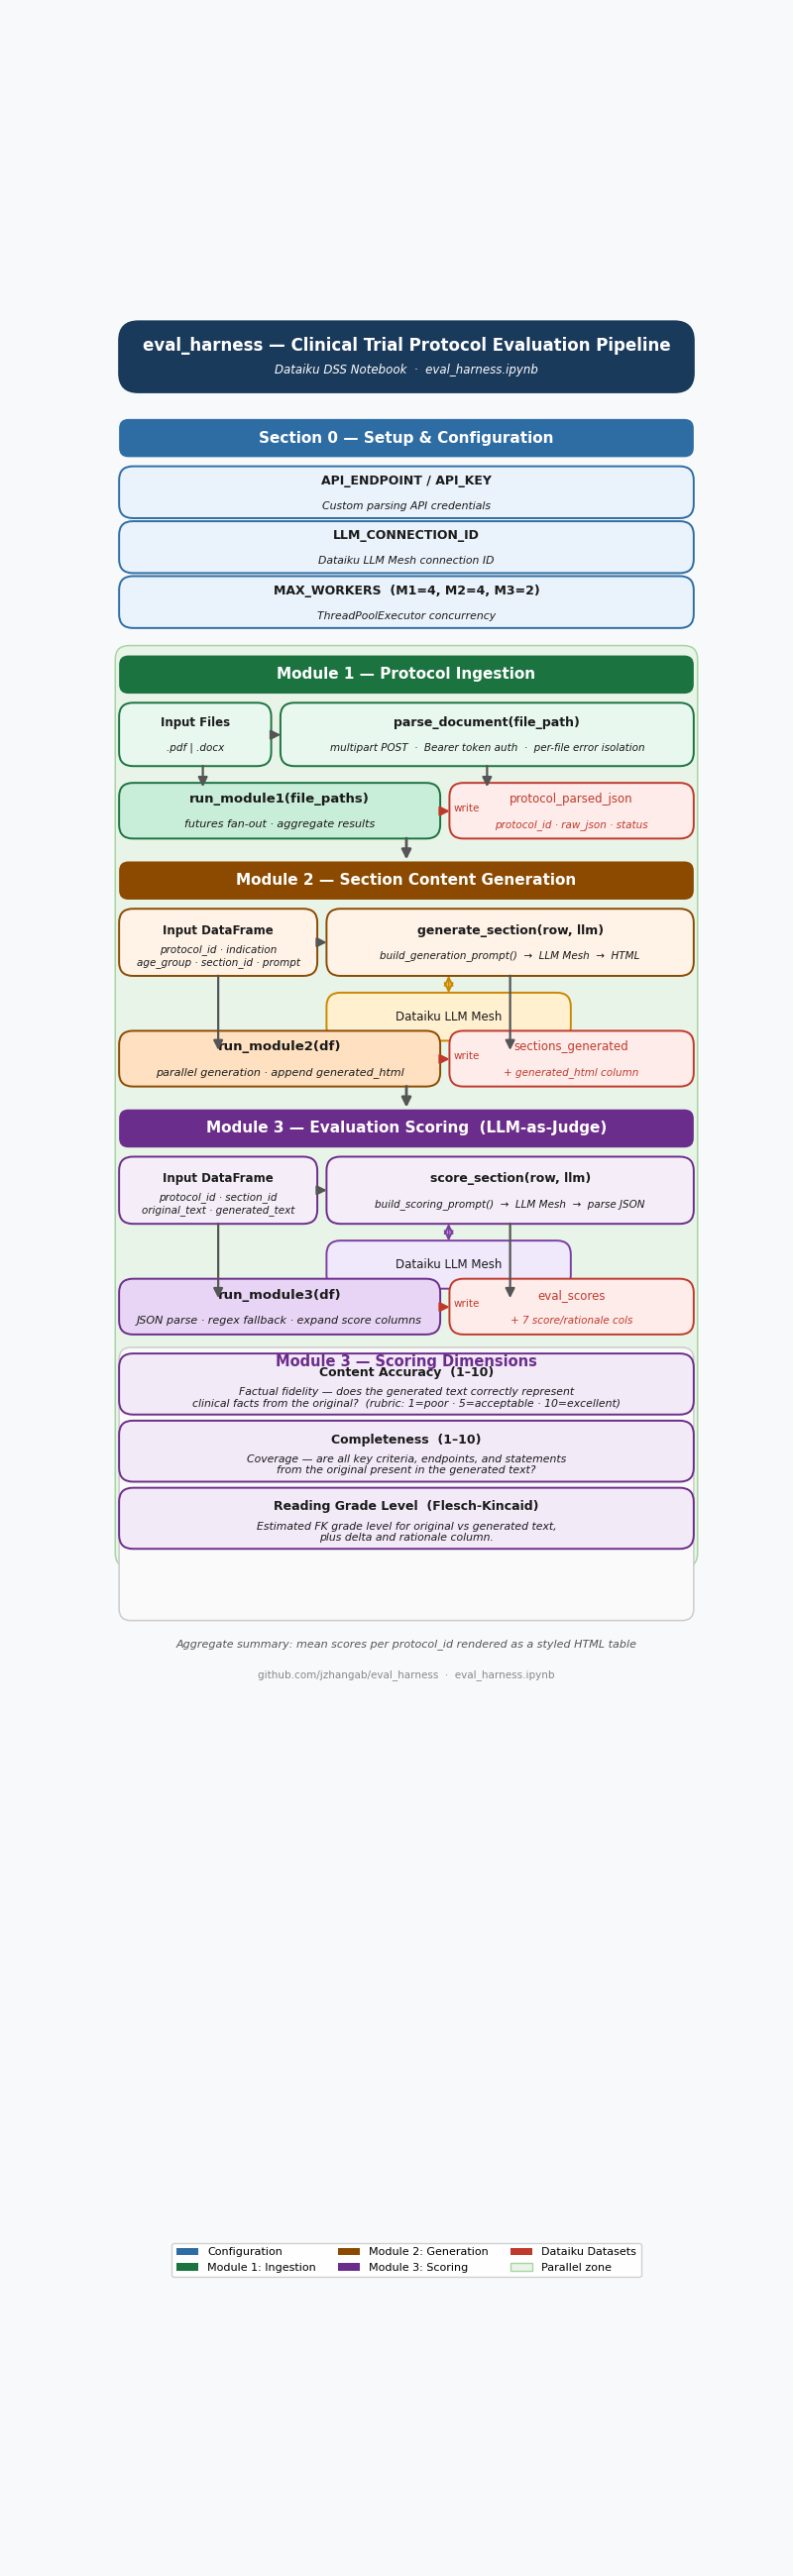


# eval_harness
**Clinical Trial Protocol — Content Generation Evaluation Pipeline**

| Module | Purpose | Input | Output |
|--------|---------|-------|--------|
| 1 | Protocol Ingestion | PDF / Word file paths | `protocol_parsed_json` dataset |
| 2 | Section Generation | DataFrame with context + prompt | `sections_generated` dataset |
| 3 | Evaluation Scoring | DataFrame with original + generated text | `eval_scores` dataset |

**Parallelism:** Modules 1 and 2 use `ThreadPoolExecutor`. Module 3 defaults to sequential to respect LLM Mesh rate limits.

---
## Section 0 — Setup & Configuration

In [ ]:
import os
import re
import json
import mimetypes
import concurrent.futures
from pathlib import Path

import requests
import pandas as pd
from IPython.display import display, HTML

import dataiku

# ---------------------------------------------------------------------------
# Configuration — edit these values before running
# ---------------------------------------------------------------------------

# Module 1: Custom protocol-parsing API
API_ENDPOINT  = os.environ.get("PROTOCOL_API_ENDPOINT", "https://<your-api-host>/v1/parse")
API_KEY       = os.environ.get("PROTOCOL_API_KEY", "")   # set in Dataiku DSS secrets or env
API_TIMEOUT   = 120   # seconds per request

# Module 2 & 3: Dataiku LLM Mesh connection ID
# Example values: "openai:gpt-4o", "anthropic:claude-sonnet-4-6", "azure_oai:my-deployment"
LLM_CONNECTION_ID = os.environ.get("LLM_CONNECTION_ID", "openai:gpt-4o")

# Parallelism
MODULE1_WORKERS = 4   # parallel document API calls
MODULE2_WORKERS = 4   # parallel LLM generation calls
MODULE3_WORKERS = 2   # set to 1 for strict sequential; increase only if rate limits allow

# Optional: map filename stems to explicit protocol IDs
# e.g. {"MyProtocol_v3": "PROT-2024-001"}
PROTOCOL_ID_OVERRIDE: dict[str, str] = {}

print("Configuration loaded.")
print(f"  API_ENDPOINT     : {API_ENDPOINT}")
print(f"  LLM_CONNECTION_ID: {LLM_CONNECTION_ID}")
print(f"  Workers (M1/M2/M3): {MODULE1_WORKERS}/{MODULE2_WORKERS}/{MODULE3_WORKERS}")

---
## Module 1 — Protocol Ingestion

Calls the external parsing API with each PDF or Word document in parallel.  
Stores the returned JSON objects in the `protocol_parsed_json` Dataiku dataset.

**Input:** `FILE_PATHS` — list of absolute file paths to `.pdf` or `.docx` files.  
**Output:** Dataiku dataset `protocol_parsed_json` with columns `[protocol_id, file_name, raw_json, status, error]`.

In [ ]:
# ── Module 1 helpers ────────────────────────────────────────────────────────

MIME_MAP = {
    ".pdf":  "application/pdf",
    ".docx": "application/vnd.openxmlformats-officedocument.wordprocessingml.document",
    ".doc":  "application/msword",
}


def _derive_protocol_id(file_path: str) -> str:
    """Return protocol ID from filename stem, respecting PROTOCOL_ID_OVERRIDE."""
    stem = Path(file_path).stem
    return PROTOCOL_ID_OVERRIDE.get(stem, stem)


def parse_document(file_path: str) -> dict:
    """
    Upload a single PDF or Word document to the external parsing API.

    Returns a dict with keys:
        protocol_id, file_name, raw_json, status, error
    """
    file_path = str(file_path)
    protocol_id = _derive_protocol_id(file_path)
    file_name   = Path(file_path).name
    suffix      = Path(file_path).suffix.lower()
    mime_type   = MIME_MAP.get(suffix, "application/octet-stream")

    try:
        with open(file_path, "rb") as fh:
            response = requests.post(
                API_ENDPOINT,
                headers={"Authorization": f"Bearer {API_KEY}"},
                files={"file": (file_name, fh, mime_type)},
                timeout=API_TIMEOUT,
            )
        response.raise_for_status()
        return {
            "protocol_id": protocol_id,
            "file_name":   file_name,
            "raw_json":    json.dumps(response.json()),
            "status":      "success",
            "error":       None,
        }
    except Exception as exc:  # noqa: BLE001
        return {
            "protocol_id": protocol_id,
            "file_name":   file_name,
            "raw_json":    None,
            "status":      "error",
            "error":       str(exc),
        }


def get_parsed(df: pd.DataFrame, protocol_id: str) -> dict:
    """Convenience helper: deserialize raw_json for a given protocol_id."""
    row = df.loc[df["protocol_id"] == protocol_id]
    if row.empty:
        raise KeyError(f"protocol_id '{protocol_id}' not found in dataframe.")
    raw = row.iloc[0]["raw_json"]
    return json.loads(raw) if raw else {}


def run_module1(file_paths: list) -> pd.DataFrame:
    """
    Process all documents in parallel and return a consolidated DataFrame.
    Also writes results to the Dataiku dataset 'protocol_parsed_json'.
    """
    print(f"Module 1: submitting {len(file_paths)} document(s) with {MODULE1_WORKERS} workers...")
    results = []

    with concurrent.futures.ThreadPoolExecutor(max_workers=MODULE1_WORKERS) as executor:
        future_map = {executor.submit(parse_document, fp): fp for fp in file_paths}
        for future in concurrent.futures.as_completed(future_map):
            result = future.result()
            status_icon = "✓" if result["status"] == "success" else "✗"
            print(f"  {status_icon} {result['file_name']} → {result['status']}")
            if result["error"]:
                print(f"    Error: {result['error']}")
            results.append(result)

    df = pd.DataFrame(results, columns=["protocol_id", "file_name", "raw_json", "status", "error"])

    # Write to Dataiku dataset
    out_ds = dataiku.Dataset("protocol_parsed_json")
    out_ds.write_dataframe(df)
    print(f"\nModule 1 complete. {len(df)} row(s) written to 'protocol_parsed_json'.")
    return df


print("Module 1 helpers defined.")

In [ ]:
# ── Module 1 execution ───────────────────────────────────────────────────────
# Edit FILE_PATHS to point at your protocol documents.
# Accepts absolute paths or paths relative to this notebook.

FILE_PATHS = [
    # "/path/to/PROT-2024-001.pdf",
    # "/path/to/PROT-2024-002.docx",
]

if FILE_PATHS:
    df_parsed = run_module1(FILE_PATHS)
    display(df_parsed[["protocol_id", "file_name", "status", "error"]])
else:
    print("No FILE_PATHS provided. Add file paths above and re-run.")

---
## Module 2 — Section Content Generation

Generates HTML-formatted section content for each row using Dataiku LLM Mesh.  
Runs in parallel across rows via `ThreadPoolExecutor`.

**Input DataFrame columns:** `protocol_id, indication, age_group, section_id, context_text, prompt`  
**Output:** Same DataFrame with an additional `generated_html` column, written to `sections_generated`.

In [ ]:
# ── Module 2 helpers ────────────────────────────────────────────────────────

SYSTEM_PROMPT_GENERATION = """\
You are an expert medical writer specializing in clinical trial protocol documents.
Your task is to generate a clearly written, accurate section of a clinical trial protocol.

Requirements:
- Output must be valid, well-formed HTML using appropriate tags: <h2>, <h3>, <p>, <ul>, <li>, <strong>.
- Write at a professional but accessible level appropriate for the specified age group.
- Be precise and factually consistent with the provided context text.
- Do not include any markdown, code fences, or commentary outside of HTML.
"""


def build_generation_prompt(row: pd.Series) -> str:
    """Construct the full generation prompt for a single section row."""
    return (
        f"Protocol ID   : {row['protocol_id']}\n"
        f"Indication    : {row['indication']}\n"
        f"Age Group     : {row['age_group']}\n"
        f"Section ID    : {row['section_id']}\n"
        f"\n--- Context Text ---\n{row['context_text']}\n"
        f"\n--- Task ---\n{row['prompt']}\n"
        f"\nGenerate the section content as HTML:"
    )


def generate_section(row: pd.Series, llm) -> str:
    """
    Call Dataiku LLM Mesh to generate HTML content for a single section.
    Returns the generated HTML string, or an HTML error message on failure.
    """
    try:
        completion = llm.new_completion()
        completion.with_message(SYSTEM_PROMPT_GENERATION, role="system")
        completion.with_message(build_generation_prompt(row))
        resp = completion.execute()
        return resp.text
    except Exception as exc:  # noqa: BLE001
        return (
            f'<p class="error"><strong>Generation error for section '
            f"{row['section_id']}: {exc}</strong></p>"
        )


def run_module2(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Generate HTML content for all rows in parallel.
    Returns input DataFrame with 'generated_html' column appended.
    Also writes results to Dataiku dataset 'sections_generated'.
    """
    required_cols = {"protocol_id", "indication", "age_group", "section_id", "context_text", "prompt"}
    missing = required_cols - set(df_input.columns)
    if missing:
        raise ValueError(f"Input DataFrame missing columns: {missing}")

    # Initialise LLM Mesh handle (shared across threads — thread-safe)
    client  = dataiku.api_client()
    project = client.get_default_project()
    llm     = project.get_llm(LLM_CONNECTION_ID)

    rows   = [row for _, row in df_input.iterrows()]
    n      = len(rows)
    print(f"Module 2: generating content for {n} section(s) with {MODULE2_WORKERS} workers...")

    generated_html = [None] * n

    with concurrent.futures.ThreadPoolExecutor(max_workers=MODULE2_WORKERS) as executor:
        future_map = {
            executor.submit(generate_section, row, llm): idx
            for idx, row in enumerate(rows)
        }
        for future in concurrent.futures.as_completed(future_map):
            idx = future_map[future]
            generated_html[idx] = future.result()
            row = rows[idx]
            print(f"  ✓ {row['protocol_id']} / {row['section_id']}")

    df_out = df_input.copy()
    df_out["generated_html"] = generated_html

    # Write to Dataiku dataset
    out_ds = dataiku.Dataset("sections_generated")
    out_ds.write_dataframe(df_out)
    print(f"\nModule 2 complete. {len(df_out)} row(s) written to 'sections_generated'.")
    return df_out


print("Module 2 helpers defined.")

In [ ]:
# ── Module 2 execution ───────────────────────────────────────────────────────
# Option A: load from the 'protocol_parsed_json' Dataiku dataset produced by Module 1.
# Option B: supply a DataFrame directly (e.g. from a CSV or another dataset).

# --- Option A ---
# df_sections_input = dataiku.Dataset("<your-sections-input-dataset>").get_dataframe()

# --- Option B: minimal inline example for testing ---
df_sections_input = pd.DataFrame([
    {
        "protocol_id":   "PROT-2024-001",
        "indication":    "Non-Small Cell Lung Cancer",
        "age_group":     "Adult (18+)",
        "section_id":    "3.1 Study Objectives",
        "context_text":  "The primary objective is to evaluate the efficacy of Drug X vs placebo "
                         "in patients with stage IIIB/IV NSCLC who have progressed on prior platinum-based therapy.",
        "prompt":        "Write the Study Objectives section for the clinical trial protocol.",
    },
])

df_generated = run_module2(df_sections_input)

# Preview generated HTML inline
for _, row in df_generated.iterrows():
    print(f"\n=== {row['protocol_id']} / {row['section_id']} ===")
    display(HTML(row["generated_html"]))

---
## Module 3 — Evaluation Scoring

LLM-as-judge framework that scores generated sections against the original text.  
Three dimensions are evaluated, each returning a 1–10 score and a brief rationale.

| Metric | Definition |
|--------|------------|
| `content_accuracy` | Factual fidelity: does the generated text correctly represent clinical facts from the original? |
| `completeness` | Coverage: are all key criteria, endpoints, and statements from the original present? |
| `reading_grade_level` | Estimated Flesch-Kincaid grade level for both texts (original and generated), plus delta rationale |

**Input DataFrame columns:** `protocol_id, section_id, original_text, generated_text`  
**Output:** Same DataFrame with 7 additional columns, written to `eval_scores`.

In [ ]:
# ── Module 3 helpers ────────────────────────────────────────────────────────

SYSTEM_PROMPT_SCORING = """\
You are an expert evaluator of clinical trial protocol documents.
You will be given an ORIGINAL text excerpt and a GENERATED text excerpt from the same protocol section.
Your task is to evaluate the generated text across three dimensions.

Scoring rubric (apply to content_accuracy_score and completeness_score):
  1-2 : Poor       — major errors, omissions, or fabrications
  3-4 : Below avg  — several notable gaps or inaccuracies
  5-6 : Acceptable — mostly correct with minor gaps
  7-8 : Good       — accurate and nearly complete, minor stylistic issues only
  9-10: Excellent  — fully accurate, complete, and well-structured

For reading_grade_level_original and reading_grade_level_generated:
  Estimate the Flesch-Kincaid US grade level (e.g. 12.5, 16.0) for each text.

Return ONLY a valid JSON object in exactly this format (no markdown, no extra text):
{
  "content_accuracy_score": <integer 1-10>,
  "content_accuracy_rationale": "<one or two sentences>",
  "completeness_score": <integer 1-10>,
  "completeness_rationale": "<one or two sentences>",
  "reading_grade_level_original": <float>,
  "reading_grade_level_generated": <float>,
  "reading_grade_level_rationale": "<one or two sentences>"
}
"""

_SCORE_FIELDS = [
    "content_accuracy_score",
    "content_accuracy_rationale",
    "completeness_score",
    "completeness_rationale",
    "reading_grade_level_original",
    "reading_grade_level_generated",
    "reading_grade_level_rationale",
]

_ERROR_ROW = {field: None for field in _SCORE_FIELDS}


def build_scoring_prompt(row: pd.Series) -> str:
    """Build the user-turn scoring prompt for a single section."""
    return (
        f"Protocol ID : {row['protocol_id']}\n"
        f"Section ID  : {row['section_id']}\n"
        f"\n=== ORIGINAL TEXT ===\n{row['original_text']}\n"
        f"\n=== GENERATED TEXT ===\n{row['generated_text']}\n"
        f"\nProvide your evaluation as JSON:"
    )


def _parse_llm_json(text: str) -> dict:
    """Extract and parse JSON from LLM response; tolerates minor formatting deviations."""
    # Try direct parse first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # Fall back: extract the first {...} block
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        return json.loads(match.group())
    raise ValueError(f"No JSON object found in LLM response: {text[:200]}")


def score_section(row: pd.Series, llm) -> dict:
    """
    Score a single section using LLM Mesh.
    Returns a dict with _SCORE_FIELDS keys.
    On failure, returns _ERROR_ROW with a populated error_message key.
    """
    try:
        completion = llm.new_completion()
        completion.with_message(SYSTEM_PROMPT_SCORING, role="system")
        completion.with_message(build_scoring_prompt(row))
        resp   = completion.execute()
        scores = _parse_llm_json(resp.text)
        # Ensure all expected fields are present
        return {field: scores.get(field) for field in _SCORE_FIELDS}
    except Exception as exc:  # noqa: BLE001
        err = dict(_ERROR_ROW)
        err["content_accuracy_rationale"] = f"SCORING ERROR: {exc}"
        return err


def run_module3(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Score all section rows (parallel when MODULE3_WORKERS > 1).
    Returns input DataFrame with score columns appended.
    Also writes results to Dataiku dataset 'eval_scores'.
    """
    required_cols = {"protocol_id", "section_id", "original_text", "generated_text"}
    missing = required_cols - set(df_input.columns)
    if missing:
        raise ValueError(f"Input DataFrame missing columns: {missing}")

    client  = dataiku.api_client()
    project = client.get_default_project()
    llm     = project.get_llm(LLM_CONNECTION_ID)

    rows   = [row for _, row in df_input.iterrows()]
    n      = len(rows)
    print(f"Module 3: scoring {n} section(s) with {MODULE3_WORKERS} worker(s)...")

    score_results = [None] * n

    with concurrent.futures.ThreadPoolExecutor(max_workers=MODULE3_WORKERS) as executor:
        future_map = {
            executor.submit(score_section, row, llm): idx
            for idx, row in enumerate(rows)
        }
        for future in concurrent.futures.as_completed(future_map):
            idx = future_map[future]
            score_results[idx] = future.result()
            row = rows[idx]
            scores = score_results[idx]
            print(
                f"  ✓ {row['protocol_id']} / {row['section_id']} "
                f"— accuracy={scores.get('content_accuracy_score')}, "
                f"completeness={scores.get('completeness_score')}, "
                f"grade_orig={scores.get('reading_grade_level_original')}, "
                f"grade_gen={scores.get('reading_grade_level_generated')}"
            )

    df_scores = pd.DataFrame(score_results, columns=_SCORE_FIELDS)
    df_out    = pd.concat([df_input.reset_index(drop=True), df_scores], axis=1)

    # Write to Dataiku dataset
    out_ds = dataiku.Dataset("eval_scores")
    out_ds.write_dataframe(df_out)
    print(f"\nModule 3 complete. {len(df_out)} row(s) written to 'eval_scores'.")
    return df_out


print("Module 3 helpers defined.")

In [ ]:
# ── Module 3 execution ───────────────────────────────────────────────────────
# Option A: load from the 'sections_generated' Dataiku dataset produced by Module 2.
# Option B: supply a DataFrame directly.

# --- Option A ---
# df_eval_input = dataiku.Dataset("sections_generated").get_dataframe()[
#     ["protocol_id", "section_id", "context_text", "generated_html"]
# ].rename(columns={"context_text": "original_text", "generated_html": "generated_text"})

# --- Option B: minimal inline example for testing ---
df_eval_input = pd.DataFrame([
    {
        "protocol_id":    "PROT-2024-001",
        "section_id":     "3.1 Study Objectives",
        "original_text":  "The primary objective is to evaluate the efficacy of Drug X vs placebo "
                          "in patients with stage IIIB/IV NSCLC who have progressed on prior platinum-based therapy.",
        "generated_text": "<h2>3.1 Study Objectives</h2><p>This study evaluates Drug X compared to "
                          "placebo in adult patients with advanced non-small cell lung cancer (stage IIIB/IV) "
                          "following failure of platinum-based chemotherapy.</p>",
    },
])

df_scores = run_module3(df_eval_input)

In [ ]:
# ── Module 3 summary view ────────────────────────────────────────────────────

numeric_cols = ["content_accuracy_score", "completeness_score",
                "reading_grade_level_original", "reading_grade_level_generated"]

df_summary = (
    df_scores
    .groupby("protocol_id")[numeric_cols]
    .mean()
    .round(2)
    .reset_index()
)
df_summary["reading_grade_level_delta"] = (
    df_summary["reading_grade_level_generated"] - df_summary["reading_grade_level_original"]
).round(2)

display(
    HTML(
        df_summary.style
        .set_caption("Evaluation Summary — Mean Scores by Protocol")
        .background_gradient(subset=["content_accuracy_score", "completeness_score"], cmap="RdYlGn", vmin=1, vmax=10)
        .format(precision=2)
        .to_html()
    )
)

print("\nDetailed scores per section:")
display(
    df_scores[[
        "protocol_id", "section_id",
        "content_accuracy_score", "content_accuracy_rationale",
        "completeness_score", "completeness_rationale",
        "reading_grade_level_original", "reading_grade_level_generated",
        "reading_grade_level_rationale",
    ]]
)